In [1]:
import csv
import os
from urllib import request
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["GLOG_minloglevel"] = "2"

import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

BaseOptions = mp.tasks.BaseOptions
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

In [2]:
BASE_DIR = Path.cwd().parent

MODEL_DIR = os.path.normpath(os.path.join(BASE_DIR, "models"))
MODEL_PATH = os.path.join(MODEL_DIR, "hand_landmarker.task")
MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
)

DATA_DIR = os.path.normpath(os.path.join(BASE_DIR, "data", "raw", "train"))
OUTPUT_DIR = os.path.normpath(os.path.join(BASE_DIR, "data", "processed"))
OUTPUT_CSV = os.path.join(OUTPUT_DIR, "landmarks.csv")

In [3]:
def ensure_model_exists():
    if not os.path.exists(MODEL_DIR):
        os.makedirs(MODEL_DIR)

    if not os.path.exists(MODEL_PATH):
        print(f"Downloading MediaPipe model to {MODEL_PATH}...")
        try:
            request.urlretrieve(MODEL_URL, MODEL_PATH)
            print("Download complete.")
        except Exception as e:
            print(f"Error downloading model: {e}")
            raise


ensure_model_exists()

In [4]:
processing_stats = {}

if not os.path.exists(DATA_DIR):
    print(f"Directory not found: {DATA_DIR}")
else:
    if os.path.exists(OUTPUT_CSV):
        print(f"Warning: File {OUTPUT_CSV} already exists and will be overwritten.")

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    classes = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])

    options = HandLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=MODEL_PATH),
        running_mode=VisionRunningMode.IMAGE,
        num_hands=1,
        min_hand_detection_confidence=0.5,
    )

    total_processed = 0

    with (
        HandLandmarker.create_from_options(options) as landmarker,
        open(OUTPUT_CSV, mode="w", newline="", encoding="utf-8") as f,
    ):
        writer = csv.writer(f)
        header = ["label_name", "label_id"] + [f"coord_{i}" for i in range(42)]
        writer.writerow(header)

        for class_id, class_name in enumerate(classes):
            class_dir = os.path.join(DATA_DIR, class_name)

            files = [
                file_name
                for file_name in sorted(os.listdir(class_dir))
                if file_name.lower().endswith((".png", ".jpg", ".jpeg", ".webp"))
            ]

            valid_images = 0
            unreadable_files = 0
            no_hand_detected = 0
            batch_rows = []

            for file_name in tqdm(files, desc=class_name, leave=True):
                img_path = os.path.join(class_dir, file_name)
                image = cv2.imread(img_path)

                if image is None:
                    unreadable_files += 1
                    continue

                image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)

                result = landmarker.detect(mp_image)

                if not result.hand_landmarks:
                    no_hand_detected += 1
                    continue

                landmarks = result.hand_landmarks[0]
                base_x, base_y = landmarks[0].x, landmarks[0].y

                translated_coords = []
                for landmark in landmarks:
                    translated_coords.append((landmark.x - base_x, landmark.y - base_y))

                flat_abs_coords = [abs(val) for pair in translated_coords for val in pair]
                max_value = max(flat_abs_coords) if flat_abs_coords else 1.0
                if max_value == 0: max_value = 1.0

                row = [class_name, str(class_id)]
                for x, y in translated_coords:
                    norm_x, norm_y = x / max_value, y / max_value
                    row.extend([f"{norm_x:.6f}", f"{norm_y:.6f}"])

                batch_rows.append(row)
                valid_images += 1

            if batch_rows:
                writer.writerows(batch_rows)

            processing_stats[class_name] = {
                "success": valid_images,
                "no_hand": no_hand_detected,
                "error": unreadable_files
            }

            total_processed += valid_images
            print(f"[{class_name}] Success: {valid_images} | No hands: {no_hand_detected}\n")

    print(f"Processing complete. Total samples saved: {total_processed}")

call:   0%|          | 0/2500 [00:00<?, ?it/s]

[call] Success: 2249 | No hands: 251



dislike:   0%|          | 0/2500 [00:00<?, ?it/s]

[dislike] Success: 2112 | No hands: 388



fist:   0%|          | 0/2500 [00:00<?, ?it/s]

...

[three3] Success: 2418 | No hands: 82



two_up:   0%|          | 0/2500 [00:00<?, ?it/s]

[two_up] Success: 2286 | No hands: 214



two_up_inverted:   0%|          | 0/2500 [00:00<?, ?it/s]

[two_up_inverted] Success: 2193 | No hands: 307

Processing complete. Total samples saved: 51449


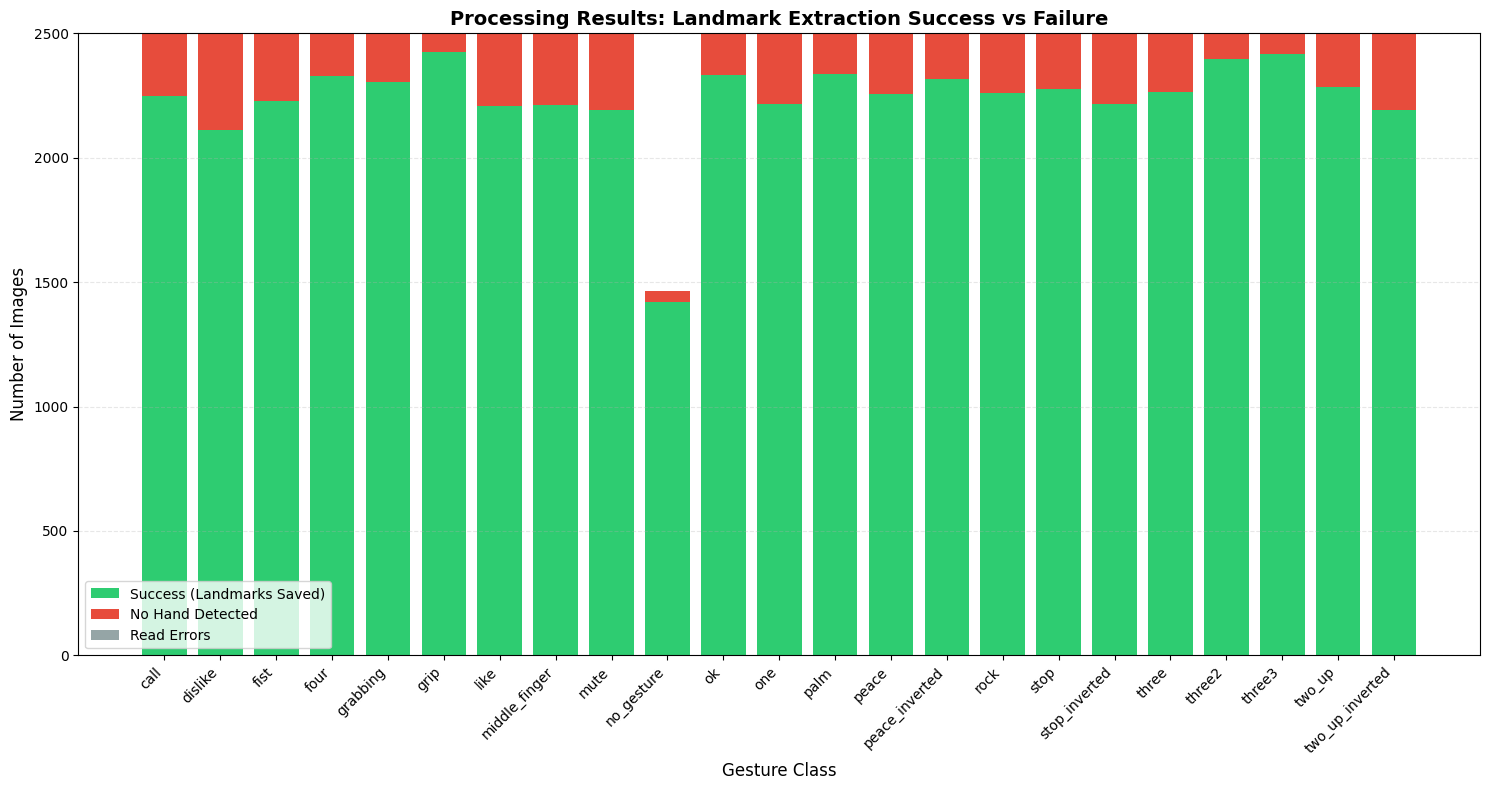

In [5]:
if processing_stats is not None:
    plt.figure(figsize=(15, 8))

    classes = list(processing_stats.keys())
    successes = [processing_stats[c]["success"] for c in classes]
    no_hands = [processing_stats[c]["no_hand"] for c in classes]
    errors = [processing_stats[c]["error"] for c in classes]

    plt.bar(classes, successes, label='Success (Landmarks Saved)', color='#2ecc71')
    plt.bar(classes, no_hands, bottom=successes, label='No Hand Detected', color='#e74c3c')
    plt.bar(classes, errors, bottom=[s + n for s, n in zip(successes, no_hands)], label='Read Errors', color='#95a5a6')

    plt.xlabel('Gesture Class', fontsize=12)
    plt.ylabel('Number of Images', fontsize=12)
    plt.title('Processing Results: Landmark Extraction Success vs Failure', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()